<a href="https://colab.research.google.com/github/apurvi-shukla/Bollywood-box-office-analytics/blob/main/Project_1_Bollywood%20movie%20analysis" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
df = pd.read_csv('archive.zip')
df.info()
df.head(5)
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1000 non-null   int64 
 1   SN           1000 non-null   int64 
 2   Movie        1000 non-null   object
 3   Worldwide    1000 non-null   int64 
 4   India Net    1000 non-null   int64 
 5   India Gross  1000 non-null   int64 
 6   Overseas     1000 non-null   int64 
 7   Budget       1000 non-null   int64 
 8   Verdict      1000 non-null   object
dtypes: int64(7), object(2)
memory usage: 70.4+ KB
(1000, 9)


In [7]:
df = df.drop(columns=['Unnamed: 0'])

print("=== HEAD ===")
display(df.head(10))

print("=== DESCRIBE ===")
display(df.describe())

print("=== ZEROS / NEGATIVES ===")
for c in ['Worldwide','India Net','India Gross','Overseas','Budget']:
    print(c, "-> zeros:", (df[c]==0).sum(), "| negative:", (df[c]<0).sum())

print("=== VERDICT ===")
print(df['Verdict'].value_counts())

print("=== SN ===")
print("SN sorted:", df['SN'].is_monotonic_increasing)

print("=== DUPLICATE TITLES ===")
print(df['Movie'].duplicated().sum())

print("=== WORLDWIDE CHECK ===")
print(((df['India Gross'] + df['Overseas']) - df['Worldwide']).describe())

=== HEAD ===


,SN,Movie,Worldwide,India Net,India Gross,Overseas,Budget,Verdict
0,1,Pathaan,10500000000,5240000000,6570000000,3920000000,2500000000,All Time Blockbuster
1,2,Baahubali 2 The Conclusion,17880000000,5100000000,14160000000,3710000000,2500000000,All Time Blockbuster
2,3,KGF Chapter 2,12080000000,4350000000,10000000000,2070000000,1000000000,All Time Blockbuster
3,4,Dangal,20700000000,3740000000,5350000000,15350000000,700000000,All Time Blockbuster
4,5,Sanju,5880000000,3420000000,4380000000,1500000000,1000000000,All Time Blockbuster
5,6,PK,7920000000,3400000000,4890000000,3030000000,850000000,All Time Blockbuster
6,7,Tiger Zinda Hai,5580000000,3390000000,4330000000,1240000000,2100000000,Blockbuster
7,8,Bajrangi Bhaijaan,9220000000,3200000000,4320000000,4890000000,900000000,All Time Blockbuster
8,9,War,4710000000,3030000000,3750000000,960000000,1500000000,Blockbuster
9,10,Padmaavat,5850000000,3020000000,4000000000,1850000000,2150000000,Blockbuster


=== DESCRIBE ===


,SN,Worldwide,India Net,India Gross,Overseas,Budget
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,500.500000,1.832870e+09,4.079600e+08,6.126900e+08,9.714300e+08,5.889000e+08
std,288.819436,1.049006e+10,5.783055e+08,9.814085e+08,8.596981e+09,2.101992e+09
min,1.000000,0.000000e+00,2.000000e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,250.750000,1.600000e+08,9.000000e+07,1.400000e+08,1.000000e+07,8.000000e+07
50%,500.500000,3.700000e+08,2.000000e+08,3.100000e+08,5.000000e+07,2.000000e+08
75%,750.250000,9.025000e+08,4.600000e+08,6.825000e+08,1.500000e+08,4.000000e+08
max,1000.000000,1.897000e+11,5.240000e+09,1.416000e+10,1.690200e+11,3.200000e+10


=== ZEROS / NEGATIVES ===
Worldwide -> zeros: 13 | negative: 0
India Net -> zeros: 0 | negative: 0
India Gross -> zeros: 10 | negative: 0
Overseas -> zeros: 218 | negative: 0
Budget -> zeros: 5 | negative: 0
=== VERDICT ===
Verdict
Flop                    197
Hit                     194
Average                 134
SuperHit                112
Disaster                 85
Blockbuster              74
Below Average            68
Above Average            55
0                        51
All Time Blockbuster     30
Name: count, dtype: int64
=== SN ===
SN sorted: True
=== DUPLICATE TITLES ===
6
=== WORLDWIDE CHECK ===
count    1.000000e+03
mean    -2.487500e+08
std      2.596035e+09
min     -5.190000e+10
25%     -1.000000e+07
50%      0.000000e+00
75%      0.000000e+00
max      1.900000e+08
dtype: float64


In [8]:
cols = ['Worldwide','India Net','India Gross','Overseas','Budget']
for c in cols:
    df[c+'_cr'] = df[c] / 1e7

print("=== SN = India Net rank? ===")
print(df['India Net'].is_monotonic_decreasing)

print("=== TOP 10 BY SUSPECT COLUMNS ===")
for c in ['Worldwide_cr','Overseas_cr','Budget_cr']:
    print(c)
    display(df.nlargest(10, c)[['SN','Movie','Worldwide_cr','India Gross_cr','Overseas_cr','Budget_cr','Verdict']])

print("=== WORLDWIDE MISMATCH (>5% off from India Gross + Overseas) ===")
diff = df['Worldwide'] - (df['India Gross'] + df['Overseas'])
bad = df[(diff.abs() > 0.05*df['Worldwide']) & (df['Worldwide']>0)]
print(len(bad))
display(bad[['SN','Movie','Worldwide_cr','India Gross_cr','Overseas_cr']].head(15))

print("=== GROSS/NET RATIO > 2 ===")
ratio = df['India Gross']/df['India Net']
print((ratio>2).sum())
display(df[ratio>2][['SN','Movie','India Net_cr','India Gross_cr']].head(15))

print("=== BUDGET = 0 ROWS ===")
display(df[df['Budget']==0][['SN','Movie','India Net_cr','Verdict']])

print("=== DUPLICATE TITLES ===")
display(df[df['Movie'].duplicated(keep=False)].sort_values('Movie')[['SN','Movie','India Net_cr','Budget_cr','Verdict']])

print("=== VERDICT vs ROI (India Net vs Budget) ===")
tmp = df[df['Budget']>0].copy()
tmp['ROI_net'] = (tmp['India Net'] - tmp['Budget'])/tmp['Budget']
display(tmp.groupby('Verdict')['ROI_net'].describe()[['count','min','50%','max']].round(2))

=== SN = India Net rank? ===
True
=== TOP 10 BY SUSPECT COLUMNS ===
Worldwide_cr


,SN,Movie,Worldwide_cr,India Gross_cr,Overseas_cr,Budget_cr,Verdict
78,79,Avengers End Game,18970.0,445.0,13335.0,2500.0,All Time Blockbuster
66,67,Avatar: The Way of Water,17380.0,477.0,16902.0,3200.0,Blockbuster
867,868,Top Gun: Maverick,12250.0,51.0,12199.0,1300.0,Hit
235,236,Spider-Man: No Way Home,10170.0,261.0,5640.0,1500.0,0
490,491,Black Panther: Wakanda Forever,6634.0,87.0,6546.0,1250.0,Hit
376,377,Thor: Love And Thunder,5550.0,127.0,3050.0,1900.0,Hit
395,396,Doctor Strange In The Multiverse Of Madness,5400.0,147.0,3100.0,1500.0,Average
605,606,Guardians of the Galaxy Vol. 3,4350.0,54.0,2595.0,1.0,0
487,488,Jurassic World: Dominion,4000.0,74.0,2700.0,1.0,0
639,640,Ant-Man and the Wasp: Quantumania,3890.0,55.0,2155.0,1500.0,Average


Overseas_cr


,SN,Movie,Worldwide_cr,India Gross_cr,Overseas_cr,Budget_cr,Verdict
66,67,Avatar: The Way of Water,17380.0,477.0,16902.0,3200.0,Blockbuster
78,79,Avengers End Game,18970.0,445.0,13335.0,2500.0,All Time Blockbuster
867,868,Top Gun: Maverick,12250.0,51.0,12199.0,1300.0,Hit
490,491,Black Panther: Wakanda Forever,6634.0,87.0,6546.0,1250.0,Hit
235,236,Spider-Man: No Way Home,10170.0,261.0,5640.0,1500.0,0
395,396,Doctor Strange In The Multiverse Of Madness,5400.0,147.0,3100.0,1500.0,Average
376,377,Thor: Love And Thunder,5550.0,127.0,3050.0,1900.0,Hit
486,487,Black Adam,2985.0,57.0,2927.0,1500.0,0
487,488,Jurassic World: Dominion,4000.0,74.0,2700.0,1.0,0
605,606,Guardians of the Galaxy Vol. 3,4350.0,54.0,2595.0,1.0,0


Budget_cr


...

,SN,Movie,India Net_cr,Verdict
887,888,Mughal-e-Azam,5.0,All Time Blockbuster
933,934,Sangam,3.0,Blockbuster
946,947,Gunga Jumna,3.0,All Time Blockbuster
968,969,Mere Mehboob,2.0,Blockbuster
976,977,Phool Aur Paththar,2.0,Blockbuster


=== DUPLICATE TITLES ===


,SN,Movie,India Net_cr,Budget_cr,Verdict
559,560,Aankhen,17.0,15.0,Average
646,647,Aankhen,13.0,2.0,All Time Blockbuster
47,48,Dilwale,148.0,165.0,Average
858,859,Dilwale,6.0,2.0,SuperHit
522,523,Hulchul,20.0,10.0,Hit
876,877,Hulchul,5.0,4.0,Below Average
448,449,Khoobsurat,24.0,18.0,Average
785,786,Khoobsurat,8.0,6.0,Above Average
175,176,Love Aaj Kal,66.0,50.0,Hit
292,293,Love Aaj Kal,40.0,60.0,Flop


=== VERDICT vs ROI (India Net vs Budget) ===


,count,min,50%,max
Verdict,,,,
0,51.0,-1.00,1.00,63.00
Above Average,55.0,-0.42,0.50,3.00
All Time Blockbuster,28.0,-0.95,2.95,12.25
Average,134.0,-0.99,0.20,13.00
Below Average,68.0,-0.98,0.00,0.50
Blockbuster,71.0,-0.99,2.00,19.00
Disaster,85.0,-0.95,-0.70,16.00
Flop,197.0,-1.00,-0.29,9.00
Hit,194.0,-1.00,0.80,14.00


In [9]:
import numpy as np

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

for c in ['Worldwide','India Net','India Gross','Overseas','Budget']:
    df[c+'_cr'] = df[c] / 1e7


for c in ['Budget_cr','Overseas_cr','Worldwide_cr','India Gross_cr']:
    df.loc[df[c] == 0, c] = np.nan


df['Verdict'] = df['Verdict'].astype(str).replace('0', np.nan)


df['flag_big_budget']   = df['Budget_cr'] >= 600
df['flag_gross_net']    = (df['India Gross_cr'] / df['India Net_cr']) > 2
df['flag_verdict_na']   = df['Verdict'].isna()
df['flag_ww_lt_gross']  = df['Worldwide_cr'] < df['India Gross_cr']

df['ROI_net'] = (df['India Net_cr'] - df['Budget_cr']) / df['Budget_cr']

print(df[['flag_big_budget','flag_gross_net','flag_verdict_na','flag_ww_lt_gross']].sum())

print("=== BIG BUDGET FLAGGED ===")
display(df[df['flag_big_budget']][['SN','Movie','India Net_cr','Budget_cr','Verdict']])

print("=== VERDICT MISSING (first 51) ===")
display(df[df['flag_verdict_na']][['SN','Movie','India Net_cr','Budget_cr']])

print("=== BUDGET 300-600 cr (threshold check) ===")
display(df[(df['Budget_cr']>=300)&(df['Budget_cr']<600)][['SN','Movie','India Net_cr','Budget_cr','Verdict']])

print("=== ROI > 5 (suspicious budgets) ===")
display(df[df['ROI_net']>5][['SN','Movie','India Net_cr','Budget_cr','Verdict']].head(25))

flag_big_budget     17
flag_gross_net      56
flag_verdict_na     51
flag_ww_lt_gross     6
dtype: int64
=== BIG BUDGET FLAGGED ===


,SN,Movie,India Net_cr,Budget_cr,Verdict
66,67,Avatar: The Way of Water,127.0,3200.0,Blockbuster
78,79,Avengers End Game,116.0,2500.0,All Time Blockbuster
235,236,Spider-Man: No Way Home,49.0,1500.0,NaN
376,377,Thor: Love And Thunder,29.0,1900.0,Hit
395,396,Doctor Strange In The Multiverse Of Madness,28.0,1500.0,Average
486,487,Black Adam,21.0,1500.0,NaN
490,491,Black Panther: Wakanda Forever,21.0,1250.0,Hit
639,640,Ant-Man and the Wasp: Quantumania,13.0,1500.0,Average
724,725,John Wick: Chapter 4,10.0,900.0,Hit
805,806,Eternals,7.0,1500.0,NaN


=== VERDICT MISSING (first 51) ===


,SN,Movie,India Net_cr,Budget_cr
181,182,Jab Harry Met Sejal,64.0,1.0
235,236,Spider-Man: No Way Home,49.0,1500.0
268,269,Ek Villain Returns,43.0,72.0
296,297,Antim: The Final Truth,39.0,35.0
399,400,Doctor G,27.0,25.0
410,411,Jawaani Jaaneman,27.0,40.0
414,415,Tadap,26.0,20.0
426,427,Dhobi Ghat,25.0,1.0
476,477,Chandigarh Kare Aashiqui,22.0,40.0
482,483,Rocketry: The Nambi Effect,22.0,1.0


=== BUDGET 300-600 cr (threshold check) ===


,SN,Movie,India Net_cr,Budget_cr,Verdict
13,14,RRR,272.0,550.0,Blockbuster
16,17,Brahmastra Part One: Shiva,249.0,350.0,Hit
33,34,2,190.0,543.0,Average
51,52,Saaho,145.0,350.0,Below Average
52,53,Thugs Of Hindostan,145.0,300.0,Disaster
529,530,Radhe Shyam,19.0,350.0,Disaster


=== ROI > 5 (suspicious budgets) ===


,SN,Movie,India Net_cr,Budget_cr,Verdict
15,16,The Kashmir Files,252.0,20.0,All Time Blockbuster
59,60,The Kerala Story,135.0,15.0,Blockbuster
60,61,Toilet Ek Prem Katha,134.0,18.0,SuperHit
133,134,Sairat,80.0,4.0,Blockbuster
156,157,Hum Aapke Hain Koun..!,72.0,6.0,All Time Blockbuster
181,182,Jab Harry Met Sejal,64.0,1.0,NaN
218,219,Dilwale Dulhania Le Jayenge,53.0,4.0,All Time Blockbuster
269,270,Raja Hindustani,43.0,6.0,All Time Blockbuster
426,427,Dhobi Ghat,25.0,1.0,NaN
482,483,Rocketry: The Nambi Effect,22.0,1.0,NaN


In [10]:
import numpy as np


df.loc[df['Budget_cr'] == 1.0, 'Budget_cr'] = np.nan
print("Budget placeholder (1 cr) rows:", df['Budget_cr'].isna().sum())


df['os_ratio'] = df['Overseas_cr'] / df['India Gross_cr']
df['flag_hollywood_cand'] = (df['os_ratio'] > 8) | df['flag_big_budget']

print("Hollywood candidates:", df['flag_hollywood_cand'].sum())
display(df[df['flag_hollywood_cand']][['SN','Movie','India Net_cr','Overseas_cr','Budget_cr','os_ratio']]
        .sort_values('os_ratio', ascending=False))


display(df[(df['os_ratio']>4)&(df['os_ratio']<=8)][['SN','Movie','India Gross_cr','Overseas_cr','os_ratio']])


q1 = df[df['Budget_cr'].notna() & ~df['flag_hollywood_cand']].copy()
q1['ROI_net'] = (q1['India Net_cr'] - q1['Budget_cr']) / q1['Budget_cr']
print("Q1 usable rows:", len(q1))
print(q1[['Budget_cr','India Net_cr']].corr(method='spearman'))


print(df['Verdict'].value_counts(dropna=False))

Budget placeholder (1 cr) rows: 65
Hollywood candidates: 22


,SN,Movie,India Net_cr,Overseas_cr,Budget_cr,os_ratio
867,868,Top Gun: Maverick,5.0,12199.0,1300.0,239.196078
840,841,Venom: Let There Be Carnage,6.0,340.0,820.0,113.333333
490,491,Black Panther: Wakanda Forever,21.0,6546.0,1250.0,75.241379
987,988,Uncharted,2.0,670.0,900.0,67.000000
932,933,No Time To Die,3.0,1100.0,1850.0,57.894737
486,487,Black Adam,21.0,2927.0,1500.0,51.350877
605,606,Guardians of the Galaxy Vol. 3,15.0,2595.0,NaN,48.055556
639,640,Ant-Man and the Wasp: Quantumania,13.0,2155.0,1500.0,39.181818
487,488,Jurassic World: Dominion,21.0,2700.0,NaN,36.486486
66,67,Avatar: The Way of Water,127.0,16902.0,3200.0,35.433962


,SN,Movie,India Gross_cr,Overseas_cr,os_ratio


Q1 usable rows: 916
              Budget_cr  India Net_cr
Budget_cr      1.000000      0.705405
India Net_cr   0.705405      1.000000
Verdict
Flop                    197
Hit                     194
Average                 134
SuperHit                112
Disaster                 85
Blockbuster              74
Below Average            68
Above Average            55
NaN                      51
All Time Blockbuster     30
Name: count, dtype: int64


Hollywood: 20


,SN,Movie,India Gross_cr,Overseas_cr,os_ratio
952,953,Disco Dancer,6.0,94.0,15.666667
186,187,Secret Superstar,81.0,831.0,10.259259
152,153,Andhadhun,95.0,343.0,3.610526
252,253,Hichki,59.0,177.0,3.000000
3,4,Dangal,535.0,1535.0,2.869159
520,521,The Lunchbox,27.0,73.0,2.703704
166,167,Hindi Medium,96.0,237.0,2.468750
885,886,Bobby,10.0,19.0,1.900000
976,977,Phool Aur Paththar,5.0,9.0,1.800000
953,954,Seeta Aur Geeta,6.0,10.0,1.666667


core rows: 980


,count,median
Verdict,,
Disaster,82,-0.70
Flop,194,-0.29
Below Average,68,0.00
Average,128,0.20
Above Average,53,0.44
Hit,182,0.80
SuperHit,109,1.50
Blockbuster,60,1.68
All Time Blockbuster,26,2.95


rows with both: 902
is_hit_roi  0.0  1.0
is_hit              
0.0         344  181
1.0          17  360


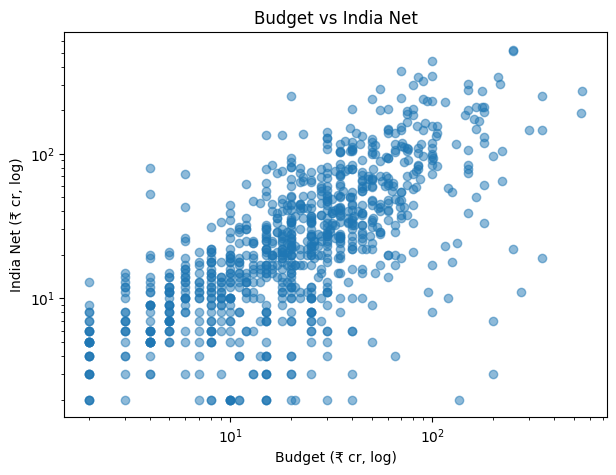

n = 918
Spearman(Budget, India Net): 0.705
Spearman(Budget, ROI):       -0.31


In [11]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt


holly_sn = [868,841,491,988,933,487,606,640,488,67,828,829,922,79,725,377,236,396,806,967]
df['is_hollywood'] = df['SN'].isin(holly_sn)
print("Hollywood:", df['is_hollywood'].sum())


display(df[~df['is_hollywood']].sort_values('os_ratio', ascending=False)
        .head(15)[['SN','Movie','India Gross_cr','Overseas_cr','os_ratio']])


south_sn = [2,3,14,34,52,73,94,124,263,360,530,599,707,930]
df['is_south'] = df['SN'].isin(south_sn)


order = ['Disaster','Flop','Below Average','Average','Above Average',
         'Hit','SuperHit','Blockbuster','All Time Blockbuster']
df['verdict_score'] = df['Verdict'].map({v:i+1 for i,v in enumerate(order)})
df['is_hit'] = (df['verdict_score'] >= 6).astype(float).where(df['verdict_score'].notna())


core = df[~df['is_hollywood']].copy()
core['ROI_net'] = (core['India Net_cr'] - core['Budget_cr']) / core['Budget_cr']
core['is_hit_roi'] = (core['ROI_net'] > 0).astype(float).where(core['ROI_net'].notna())

print("core rows:", len(core))


display(core.groupby('Verdict')['ROI_net'].agg(['count','median']).round(2).reindex(order))


both = core.dropna(subset=['is_hit','is_hit_roi'])
print("rows with both:", len(both))
print(pd.crosstab(both['is_hit'], both['is_hit_roi']))


q1 = core.dropna(subset=['Budget_cr'])
plt.figure(figsize=(7,5))
plt.scatter(q1['Budget_cr'], q1['India Net_cr'], alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Budget (₹ cr, log)'); plt.ylabel('India Net (₹ cr, log)')
plt.title('Budget vs India Net')
plt.show()

print("n =", len(q1))
print("Spearman(Budget, India Net):", round(q1['Budget_cr'].corr(q1['India Net_cr'], method='spearman'), 3))
print("Spearman(Budget, ROI):      ", round(q1['Budget_cr'].corr(q1['ROI_net'], method='spearman'), 3))

In [12]:
import numpy as np
from scipy.stats import linregress


odd = both[(both['is_hit']==1) & (both['is_hit_roi']==0)]
display(odd[['SN','Movie','India Net_cr','Budget_cr','ROI_net','Verdict','is_south']].sort_values('ROI_net'))

print(both[(both['is_hit']==0) & (both['is_hit_roi']==1)]['Verdict'].value_counts())


lq = q1[q1['India Net_cr'] > 0]
res = linregress(np.log(lq['Budget_cr']), np.log(lq['India Net_cr']))
print("slope:", round(res.slope, 2), "| R2:", round(res.rvalue**2, 2), "| n:", len(lq))


nq = q1[~q1['is_south']]
print("without South, n =", len(nq))
print("Spearman(Budget, Net):", round(nq['Budget_cr'].corr(nq['India Net_cr'], method='spearman'), 3))
print("Spearman(Budget, ROI):", round(nq['Budget_cr'].corr(nq['ROI_net'], method='spearman'), 3))

,SN,Movie,India Net_cr,Budget_cr,ROI_net,Verdict,is_south
978,979,Master,2.0,135.0,-0.985185,Blockbuster,False
799,800,Varisu,7.0,200.0,-0.965000,SuperHit,False
910,911,Dasara,4.0,65.0,-0.938462,SuperHit,False
736,737,Vikram,10.0,120.0,-0.916667,All Time Blockbuster,False
463,464,Ponniyin Selvan - Part 1,22.0,250.0,-0.912000,All Time Blockbuster,False
450,451,Enthiran,24.0,132.0,-0.818182,All Time Blockbuster,False
790,791,Sita Ramam,8.0,25.0,-0.680000,Blockbuster,False
659,660,Major,12.0,30.0,-0.600000,SuperHit,False
815,816,777 Charlie,7.0,15.0,-0.533333,Blockbuster,False
13,14,RRR,272.0,550.0,-0.505455,Blockbuster,True


Verdict
Average          104
Above Average     45
Below Average     29
Flop               3
Name: count, dtype: int64
slope: 0.72 | R2: 0.47 | n: 918
without South, n = 906
Spearman(Budget, Net): 0.704
Spearman(Budget, ROI): -0.302


In [13]:
odd = both[(both['is_hit']==1) & (both['is_hit_roi']==0)]
display(odd[['SN','Movie','India Net_cr','Overseas_cr','Worldwide_cr','Budget_cr','Verdict']])


t = core.dropna(subset=['Budget_cr','Worldwide_cr','is_hit']).copy()
t['ROI_ww'] = (t['Worldwide_cr'] - t['Budget_cr']) / t['Budget_cr']
t['is_hit_ww'] = (t['ROI_ww'] > 0).astype(int)
print("n =", len(t))
print(pd.crosstab(t['is_hit'], t['is_hit_ww']))
print("agreement ww :", round(((t['is_hit']==t['is_hit_ww']).mean())*100,1), "%")
tn = t.dropna(subset=['is_hit_roi'])
print("agreement net:", round(((tn['is_hit']==tn['is_hit_roi']).mean())*100,1), "%")

,SN,Movie,India Net_cr,Overseas_cr,Worldwide_cr,Budget_cr,Verdict
13,14,RRR,272.0,314.0,1230.0,550.0,Blockbuster
16,17,Brahmastra Part One: Shiva,249.0,113.0,431.0,350.0,Hit
63,64,Gangubai Kathiawadi,131.0,56.0,211.0,180.0,Hit
72,73,Baahubali,118.0,134.0,650.0,180.0,Blockbuster
93,94,Pushpa: The Rise (Part 1),106.0,36.0,350.0,150.0,SuperHit
128,129,My Name Is Khan,82.0,112.0,224.0,85.0,Hit
262,263,K.G.F : Chapter 1,44.0,10.0,237.0,80.0,Blockbuster
348,349,Uunchai,32.0,9.0,48.0,45.0,Hit
450,451,Enthiran,24.0,75.0,291.0,132.0,All Time Blockbuster
463,464,Ponniyin Selvan - Part 1,22.0,175.0,488.0,250.0,All Time Blockbuster


n = 899
is_hit_ww    0    1
is_hit             
0.0        157  365
1.0          0  377
agreement ww : 59.4 %
agreement net: 78.0 %


In [14]:
odd = both[(both['is_hit']==1) & (both['is_hit_roi']==0)]
print(odd[['SN','Movie','India Net_cr','Overseas_cr','Worldwide_cr','Budget_cr','Verdict','flag_gross_net']].to_string())


print("odd rows caught by gross/net flag:", odd['flag_gross_net'].sum(), "of", len(odd))


q1b = core[core['Budget_cr'].notna() & ~core['flag_gross_net']].copy()
print("n =", len(q1b), "(hataye:", core['Budget_cr'].notna().sum() - len(q1b), ")")
print("Spearman(Budget, Net):", round(q1b['Budget_cr'].corr(q1b['India Net_cr'], method='spearman'), 3))
print("Spearman(Budget, ROI):", round(q1b['Budget_cr'].corr(q1b['ROI_net'], method='spearman'), 3))

lq = q1b[q1b['India Net_cr'] > 0]
res = linregress(np.log(lq['Budget_cr']), np.log(lq['India Net_cr']))
print("slope:", round(res.slope, 2), "| R2:", round(res.rvalue**2, 2))


b2 = q1b.dropna(subset=['is_hit','is_hit_roi'])
print("agreement:", round((b2['is_hit']==b2['is_hit_roi']).mean()*100, 1), "% | n =", len(b2))
print(pd.crosstab(b2['is_hit'], b2['is_hit_roi']))

      SN                       Movie  India Net_cr  Overseas_cr  Worldwide_cr  Budget_cr               Verdict  flag_gross_net
13    14                         RRR         272.0        314.0        1230.0      550.0           Blockbuster            True
16    17  Brahmastra Part One: Shiva         249.0        113.0         431.0      350.0                   Hit           False
63    64         Gangubai Kathiawadi         131.0         56.0         211.0      180.0                   Hit           False
72    73                   Baahubali         118.0        134.0         650.0      180.0           Blockbuster            True
93    94   Pushpa: The Rise (Part 1)         106.0         36.0         350.0      150.0              SuperHit            True
128  129             My Name Is Khan          82.0        112.0         224.0       85.0                   Hit           False
262  263           K.G.F : Chapter 1          44.0         10.0         237.0       80.0           Blockbuster 

In [15]:

removed = core[core['Budget_cr'].notna() & core['flag_gross_net']]
print(len(removed))
print(removed[['SN','Movie','India Net_cr','India Gross_cr','Budget_cr','Verdict']].to_string())


f = core[(core['Verdict']=='Flop') & (core['ROI_net']>0)]
print(f[['SN','Movie','India Net_cr','Worldwide_cr','Budget_cr','ROI_net']].to_string())

final = core.drop(columns=['is_south'], errors='ignore').copy()
final['include_q1'] = final['Budget_cr'].notna() & ~final['flag_gross_net']
final.to_csv('bollywood_cleaned.csv', index=False)
print(final.shape, final['include_q1'].sum())

29
      SN                       Movie  India Net_cr  India Gross_cr  Budget_cr               Verdict
1      2  Baahubali 2 The Conclusion         510.0          1416.0      250.0  All Time Blockbuster
2      3               KGF Chapter 2         435.0          1000.0      100.0  All Time Blockbuster
13    14                         RRR         272.0           915.0      550.0           Blockbuster
33    34                           2         190.0           551.0      543.0               Average
51    52                       Saaho         145.0           359.0      350.0         Below Average
72    73                   Baahubali         118.0           516.0      180.0           Blockbuster
93    94   Pushpa: The Rise (Part 1)         106.0           313.0      150.0              SuperHit
123  124                     Kantara          84.0           363.0       16.0  All Time Blockbuster
262  263           K.G.F : Chapter 1          44.0           227.0       80.0           Blockbust

Q1 n = 891
Spearman(Budget, Net): 0.742
Spearman(Budget, ROI): -0.281
slope: 0.79 | R2: 0.53


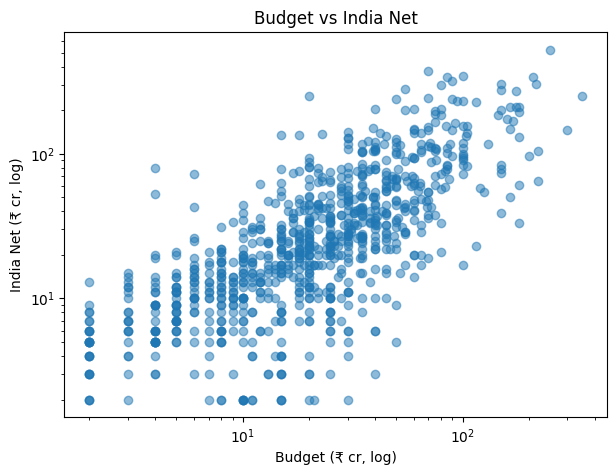

,films,median_net,median_roi
bucket,,,
"(1.999, 8.0]",189,8.0,0.86
"(8.0, 17.0]",175,15.0,0.22
"(17.0, 27.0]",171,23.0,0.08
"(27.0, 45.0]",179,38.0,0.05
"(45.0, 350.0]",177,82.0,0.02


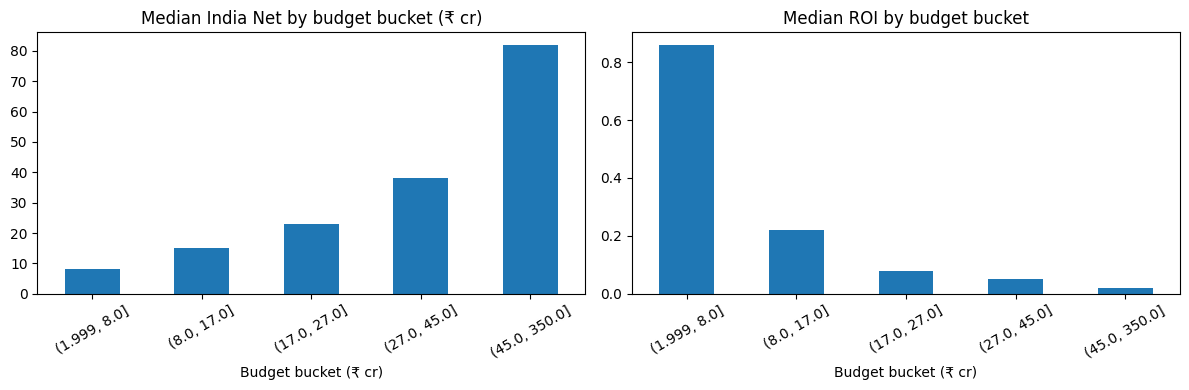

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import linregress

final.loc[final['SN'].isin([600, 696]), 'flag_gross_net'] = False
final['include_q1'] = final['Budget_cr'].notna() & ~final['flag_gross_net']
q1 = final[final['include_q1']].copy()
print("Q1 n =", len(q1))

print("Spearman(Budget, Net):", round(q1['Budget_cr'].corr(q1['India Net_cr'], method='spearman'), 3))
print("Spearman(Budget, ROI):", round(q1['Budget_cr'].corr(q1['ROI_net'], method='spearman'), 3))
r = linregress(np.log(q1['Budget_cr']), np.log(q1['India Net_cr']))
print("slope:", round(r.slope, 2), "| R2:", round(r.rvalue**2, 2))


plt.figure(figsize=(7,5))
plt.scatter(q1['Budget_cr'], q1['India Net_cr'], alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Budget (₹ cr, log)'); plt.ylabel('India Net (₹ cr, log)')
plt.title('Budget vs India Net')
plt.savefig('q1_scatter.png', dpi=150, bbox_inches='tight'); plt.show()


q1['bucket'] = pd.qcut(q1['Budget_cr'], q=5, duplicates='drop')
s = q1.groupby('bucket', observed=True).agg(
    films=('Movie','count'), median_net=('India Net_cr','median'), median_roi=('ROI_net','median')).round(2)
display(s)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
s['median_net'].plot(kind='bar', ax=ax[0], title='Median India Net by budget bucket (₹ cr)')
s['median_roi'].plot(kind='bar', ax=ax[1], title='Median ROI by budget bucket')
for a in ax: a.set_xlabel('Budget bucket (₹ cr)'); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('q1_buckets.png', dpi=150); plt.show()


final.to_csv('bollywood_cleaned.csv', index=False)
from google.colab import files
files.download('bollywood_cleaned.csv')